<a href="https://colab.research.google.com/github/Tiffany930205/0530/blob/main/lora_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# 升級 torchao 到最新版
!pip install --upgrade torchao

# 為了確保所有相依性正確，建議也同時確保 transformers 和 peft 都是最新版
!pip install --upgrade transformers peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 51.9 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 107.6 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.13.1
    Uninstalling transformers-5.13.1:
      Successfully uninstalled transformers-5.13.1


In [8]:
# 解除安裝舊版的 diffusers (以防萬一)
!pip uninstall -y diffusers

# 從 GitHub 原始碼安裝最新開發版的 diffusers，以及其他必要套件
!pip install git+https://github.com/huggingface/diffusers.git accelerate transformers xformers datasets

# 重新下載官方 LoRA 訓練腳本
!wget -O train_text_to_image_lora.py https://raw.githubusercontent.com/huggingface/diffusers/main/examples/text_to_image/train_text_to_image_lora.py

Found existing installation: diffusers 0.39.0
Uninstalling diffusers-0.39.0:
  Successfully uninstalled diffusers-0.39.0
  Cloning https://github.com/huggingface/diffusers.git to /tmp/pip-req-build-5m90kc25
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/diffusers.git /tmp/pip-req-build-5m90kc25
  Resolved https://github.com/huggingface/diffusers.git to commit 8f02e2c07f48ff2b53ced8392940e28aa9bd0019
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for diffusers: filename=diffusers-0.40.0.dev0-py3-none-any.whl size=5668913 sha256=0e505cfed95ec42a9d4a9108efe23eb334c6c5201c0594fcb414f7838ccede04
  Stored in directory: /tmp/pip-ephem-wheel-cache-5sp2amut/wheels/23/0f/7d/f97813d265ed0e599a78d83afd4e1925740896ca79b46cccfd
Successfully built diffusers
--2026-07-16 17:59:12--  https://raw.githubusercontent.com/huggingface/diffusers/main/examples/text_to_i

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
!accelerate launch train_text_to_image_lora.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --dataset_name="reach-vb/pokemon-blip-captions" \
  --dataloader_num_workers=2 \
  --resolution=512 --center_crop --random_flip \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --max_train_steps=200 \
  --learning_rate=1e-04 \
  --max_grad_norm=1 \
  --lr_scheduler="cosine" --lr_warmup_steps=0 \
  --output_dir="/content/drive/MyDrive/lora_pokemon_demo" \
  --checkpointing_steps=500 \
  --validation_prompt="Totoro" \
  --seed=1337

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so
Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorc

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


  0%|          | 0/25 [00:00<?, ?it/s]

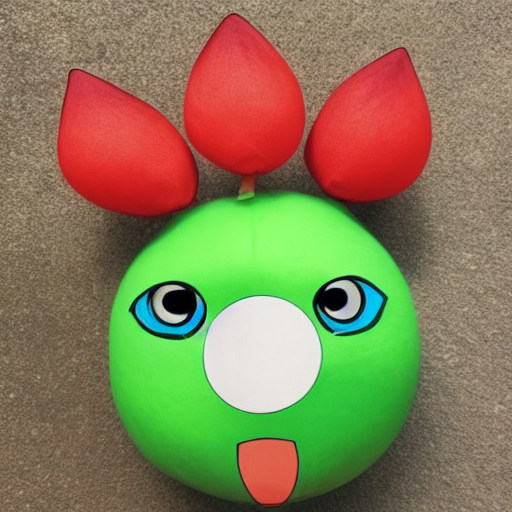

In [9]:
import torch
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler

# 1. 載入基礎模型
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)

# 2. 【更新寫法】掛載你剛剛練好的 LoRA 權重
pipe.load_lora_weights("/content/drive/MyDrive/lora_pokemon_demo")

# 3. 將模型移至 GPU
pipe.to("cuda")

# 4.讓它畫一隻有寶可夢風格的生物
prompt = "Green pokemon with watermelon face"
image = pipe(prompt, num_inference_steps=25).images[0]

# 顯示圖片
display(image)